In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import stats
import math
import statsmodels
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import metrics

import matplotlib as mpl
import matplotlib.font_manager as font_manager

#寻找峰谷值
from scipy.signal import find_peaks

plt.rcParams['font.sans-serif'] = ['SimHei'] # 步骤一（替换sans-serif字体）
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def plot_cycle(eco,name):
    fig, ax1 = plt.subplots()

    # 绘制柱状图
    #ax1.bar(eco.index, eco['周期划分'], color='b', label='周期划分')

    ax1.tick_params(axis='y', labelcolor='b')

    # 创建第二个轴
    ax2 = ax1.twinx()

    # 绘制折线图
    ax2.plot(eco.index, eco[name], color='r', label=name)

    ax2.tick_params(axis='y', labelcolor='r')
    ax1.fill_between(eco.index, eco['周期划分'], where=(eco['周期划分'] == 1), facecolor='green', alpha=0.3)
    ax1.fill_between(eco.index, eco['周期划分'], where=(eco['周期划分'] == -1), facecolor='red', alpha=0.3)
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

低频经济

In [3]:
data2=pd.read_excel('中国低频数据.xlsx',index_col=0)


PMI

<AxesSubplot:xlabel='指标名称'>

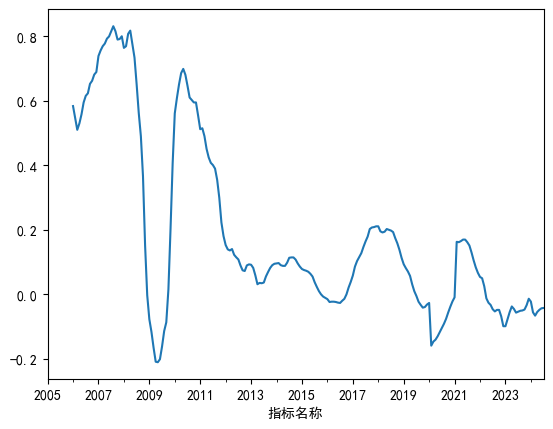

In [4]:
pmi = data2[['中国:制造业PMI']]
pmi['PMI']=pmi['中国:制造业PMI']


pmi=pmi.dropna()
pmi['PMI同比']=(1+(pmi['PMI']-50)/100).cumprod().pct_change(12)
pmi['PMI同比'].plot()


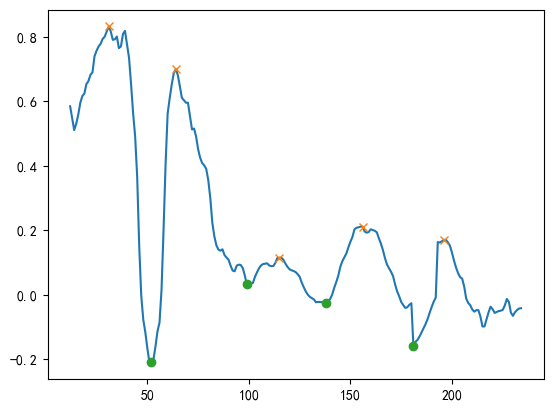

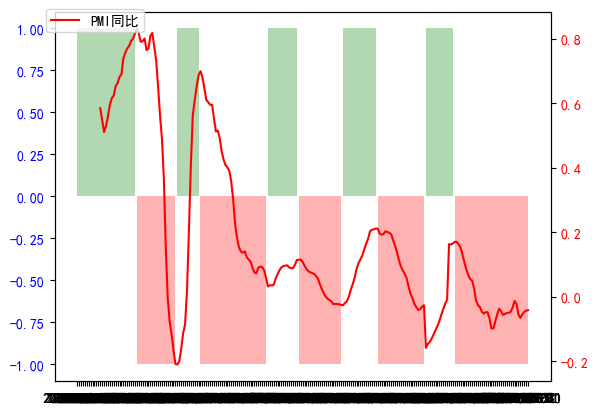

In [5]:
name='PMI同比'

def plot_pv(eco,name,width=100):

    x=eco[name].values
    #width：设置峰值的宽度要求，即峰值周围至少有多少连续点。
    #根据需求调整width宽度
    peaks, _ = find_peaks(x, width=width)
    valleys, _ = find_peaks(-x, width=width)
    plt.plot(x)
    plt.plot(peaks, x[peaks], "x")
    plt.plot(valleys, x[valleys], "o")

    df=eco[[name]]
    df['周期划分']=np.nan
    df['周期划分'].iloc[peaks]=-1
    df['周期划分'].iloc[valleys]=1
    df['周期划分'].iloc[0]=1
    df=df.fillna(method='ffill')
    df.index = df.index.astype(str)
    plot_cycle(df,name)
    df.index=pd.to_datetime(df.index)
    return df

#width函数需要调整
df=plot_pv(pmi,name,width=5)

In [6]:
Res={}
for step in range(1,13):
    for threshold in np.arange(0,0.2,0.01):

        pmi['肉眼']=df['周期划分']
        pmi['周期划分']=np.where((pmi['PMI同比']-pmi['PMI同比'].shift(1).rolling(step).mean())>threshold,1,np.where((pmi['PMI同比']-pmi['PMI同比'].shift(1).rolling(step).mean())<-threshold,-1,np.nan))
        pmi['周期划分']=pmi['周期划分'].fillna(method='ffill')

        pmi['判断']=np.where(pmi['肉眼']==pmi['周期划分'],1,np.where(pmi['肉眼']==-pmi['周期划分'],-1,np.nan))
        win=pmi['判断'].sum()/pmi['判断'].count()
        Res[str(int(step))+'_'+str(round(threshold,2))]=win

Res0=pd.DataFrame.from_dict(Res,orient='index')
Res0.sort_values(by=0,ascending=False).head(10)

,0
1_0.01,0.657658
2_0.01,0.656109
5_0.01,0.642202
3_0.01,0.636364
4_0.01,0.625571
6_0.01,0.612903
5_0.0,0.605505
6_0.0,0.603687
7_0.0,0.601852
8_0.0,0.600000


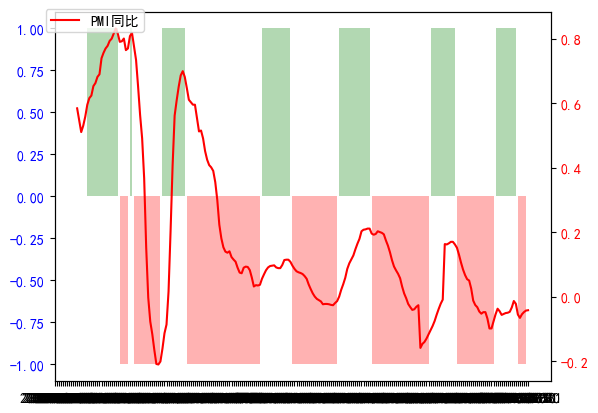

In [7]:
step=5
threshold=0.01
pmi['肉眼']=df['周期划分']
pmi['周期划分']=np.where((pmi['PMI同比']-pmi['PMI同比'].shift(1).rolling(step).mean())>threshold,1,np.where((pmi['PMI同比']-pmi['PMI同比'].shift(1).rolling(step).mean())<-threshold,-1,np.nan))
pmi['周期划分']=pmi['周期划分'].fillna(method='ffill')

pmi['判断']=np.where(pmi['肉眼']==pmi['周期划分'],1,np.where(pmi['肉眼']==-pmi['周期划分'],-1,np.nan))
win=pmi['判断'].sum()/pmi['判断'].count()
Res[str(int(step))+'_'+str(threshold)]=win
# cpi=cpi.fillna(method='bfill')
pmi.index = pmi.index.astype(str)

plot_cycle(pmi,'PMI同比')